# Sales Performance Analysis — Alfido Tech
**Task 2 of 3 — Internship Data Analytics Program**

**Dataset:** Superstore Sales Dataset (Kaggle) — `superstore_final_dataset.csv`

**Goal:** Analyze sales transactions to understand revenue trends, top-performing categories/products/regions, seasonality, and shipping performance, and provide actionable recommendations for Alfido Tech.

**Contents**
1. Setup & Data Loading
2. Data Cleaning
3. Summary Statistics & Data Types
4. Feature Engineering (date parts, shipping delay)
5. Sales Trend Analysis (yearly, monthly, seasonality)
6. Category, Sub-Category & Product Performance
7. Regional & State Performance
8. Customer Segment & Concentration Analysis
9. Shipping Mode Analysis
10. Key Findings & 5 Actionable Recommendations


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
CAT_COLORS = ["#2E5EAA", "#3FA796", "#F2A541"]
REGION_COLORS = ["#2E5EAA", "#3FA796", "#F2A541", "#D64545"]

df = pd.read_csv("superstore_final_dataset.csv", encoding="latin1")
print("Shape:", df.shape)
df.head()


Shape: (9800, 18)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   str    
 2   Order_Date     9800 non-null   str    
 3   Ship_Date      9800 non-null   str    
 4   Ship_Mode      9800 non-null   str    
 5   Customer_ID    9800 non-null   str    
 6   Customer_Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product_ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub_Category   9800 non-null   str    
 16  Product_Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

## 2. Data Cleaning

Checks performed:
- **Date format:** `Order_Date` / `Ship_Date` are in DD/MM/YYYY format (confirmed by checking for day values > 12 in the first slot) — parsed accordingly.
- **Duplicate rows:** checked, none found.
- **Missing values:** `Postal_Code` is missing for 11 rows, all in Burlington, Vermont (a known real-world ZIP quirk for that town) — left as-is since Postal_Code isn't used in this analysis.
- **Invalid values:** checked for non-positive Sales; none found.
- **Date consistency:** checked that Ship_Date is never before Order_Date; confirmed for all rows.


In [3]:
# Parse dates (DD/MM/YYYY)
first_component_max = df["Order_Date"].str.split("/").str[0].astype(int).max()
print("Max value in first date slot:", first_component_max, "-> confirms DD/MM/YYYY (day-first)")

df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], dayfirst=True)

print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

print("Missing values:\n", df.isna().sum()[df.isna().sum() > 0])
print("\nRows with missing Postal_Code:")
print(df[df["Postal_Code"].isna()][["City", "State"]].drop_duplicates())

print("\nNon-positive Sales rows:", (df["Sales"] <= 0).sum())
print("Ship_Date before Order_Date:", (df["Ship_Date"] < df["Order_Date"]).sum())

print(f"\nClean dataset: {df.shape[0]:,} line items, {df['Order_ID'].nunique():,} orders, "
      f"{df['Customer_ID'].nunique():,} customers, {df['Product_ID'].nunique():,} products")
print(f"Date range: {df['Order_Date'].min().date()} to {df['Order_Date'].max().date()}")


Max value in first date slot: 31 -> confirms DD/MM/YYYY (day-first)

Duplicate rows: 0
Missing values:
 Postal_Code    11
dtype: int64

Rows with missing Postal_Code:
            City    State
2234  Burlington  Vermont

Non-positive Sales rows: 0
Ship_Date before Order_Date: 0

Clean dataset: 9,800 line items, 4,922 orders, 793 customers, 1,861 products
Date range: 2015-01-03 to 2018-12-30


## 3. Summary Statistics & Data Types

In [4]:
df.dtypes

Row_ID                    int64
Order_ID                    str
Order_Date       datetime64[us]
Ship_Date        datetime64[us]
Ship_Mode                   str
Customer_ID                 str
Customer_Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal_Code             float64
Region                      str
Product_ID                  str
Category                    str
Sub_Category                str
Product_Name                str
Sales                   float64
dtype: object

In [5]:
df["Sales"].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

In [6]:
for col in ["Category", "Sub_Category", "Segment", "Region", "Ship_Mode"]:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())



Category value counts:
Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64

Sub_Category value counts:
Sub_Category
Binders        1492
Paper          1338
Furnishings     931
Phones          876
Storage         832
Art             785
Accessories     756
Chairs          607
Appliances      459
Labels          357
Tables          314
Envelopes       248
Bookcases       226
Fasteners       214
Supplies        184
Machines        115
Copiers          66
Name: count, dtype: int64

Segment value counts:
Segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64

Region value counts:
Region
West       3140
East       2785
Central    2277
South      1598
Name: count, dtype: int64

Ship_Mode value counts:
Ship_Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64


## 4. Feature Engineering

We extract additional date-based fields from `Order_Date` and `Ship_Date` to support trend, seasonality, and shipping analysis: calendar year, month, quarter, and weekday of each order, plus the shipping delay in days (time between order and shipment). These fields don't change any existing values — they simply unlock the groupings used in Sections 5 and 9.


In [7]:
df["Order_Year"] = df["Order_Date"].dt.year
df["Order_Month"] = df["Order_Date"].dt.month
df["Order_YearMonth"] = df["Order_Date"].dt.to_period("M").dt.to_timestamp()
df["Order_Quarter"] = df["Order_Date"].dt.to_period("Q").astype(str)
df["Order_Weekday"] = df["Order_Date"].dt.day_name()
df["Shipping_Delay_Days"] = (df["Ship_Date"] - df["Order_Date"]).dt.days

df[["Order_Date", "Order_Year", "Order_Month", "Order_Quarter", "Order_Weekday", "Shipping_Delay_Days"]].head()


,Order_Date,Order_Year,Order_Month,Order_Quarter,Order_Weekday,Shipping_Delay_Days
0,2017-11-08,2017,11,2017Q4,Wednesday,3
1,2017-11-08,2017,11,2017Q4,Wednesday,3
2,2017-06-12,2017,6,2017Q2,Monday,4
3,2016-10-11,2016,10,2016Q4,Tuesday,7
4,2016-10-11,2016,10,2016Q4,Tuesday,7


In [8]:
def money_fmt(x, pos):
    if x >= 1e6: return f"${x/1e6:.1f}M"
    if x >= 1e3: return f"${x/1e3:.0f}K"
    return f"${x:.0f}"

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]


## 5. Sales Trend Analysis

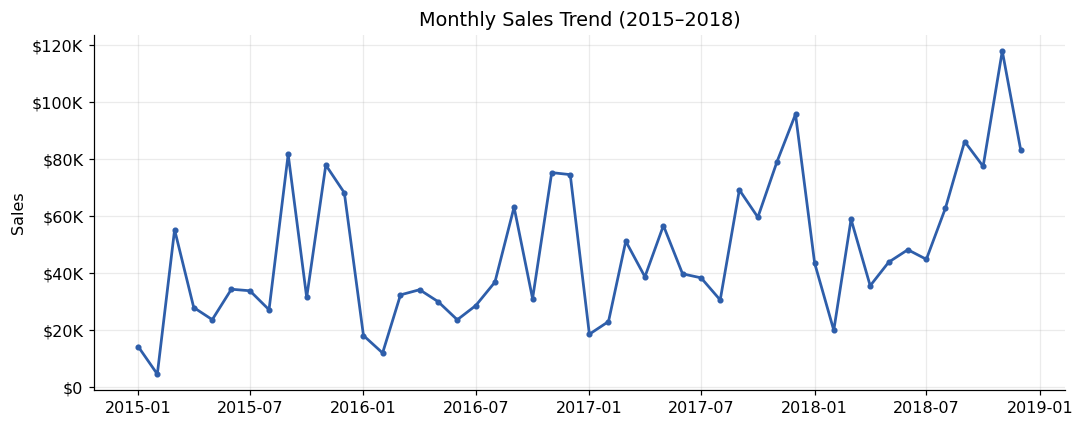

In [9]:
monthly = df.groupby("Order_YearMonth")["Sales"].sum()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly.values, color="#2E5EAA", linewidth=1.8, marker="o", markersize=3)
ax.set_title("Monthly Sales Trend (2015–2018)")
ax.set_ylabel("Sales")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
plt.tight_layout()
plt.show()


Yearly sales:
 Order_Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

YoY % change:
 Order_Year
2015     NaN
2016    -4.3
2017    30.6
2018    20.3
Name: Sales, dtype: float64


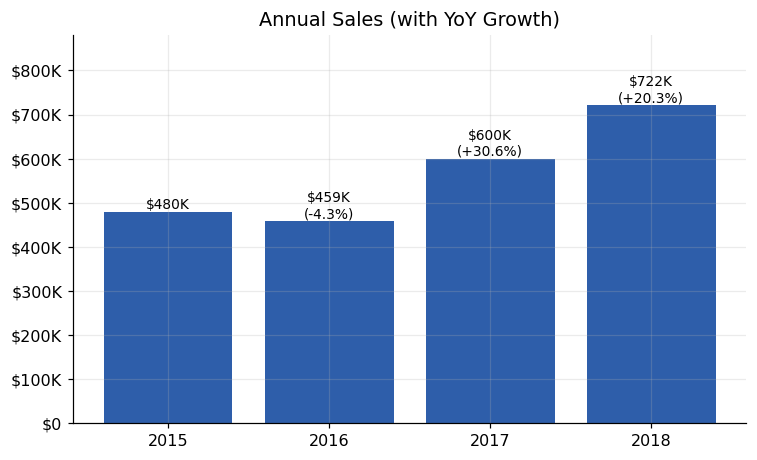

In [10]:
yearly = df.groupby("Order_Year")["Sales"].sum()
yoy = yearly.pct_change() * 100
print("Yearly sales:\n", yearly)
print("\nYoY % change:\n", yoy.round(1))

fig, ax = plt.subplots(figsize=(7, 4.3))
bars = ax.bar(yearly.index.astype(str), yearly.values, color="#2E5EAA")
ax.set_title("Annual Sales (with YoY Growth)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
for i, bar in enumerate(bars):
    label = f"${yearly.values[i]/1000:.0f}K"
    if not np.isnan(yoy.values[i]):
        label += f"\n({yoy.values[i]:+.1f}%)"
    ax.annotate(label, (bar.get_x()+bar.get_width()/2, bar.get_height()), ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, yearly.max()*1.22)
plt.tight_layout()
plt.show()


**Finding:** sales dipped slightly in 2016 (−4.3%) but then grew strongly in 2017 (+30.6%) and 2018 (+20.3%) — a healthy, accelerating growth trajectory overall.

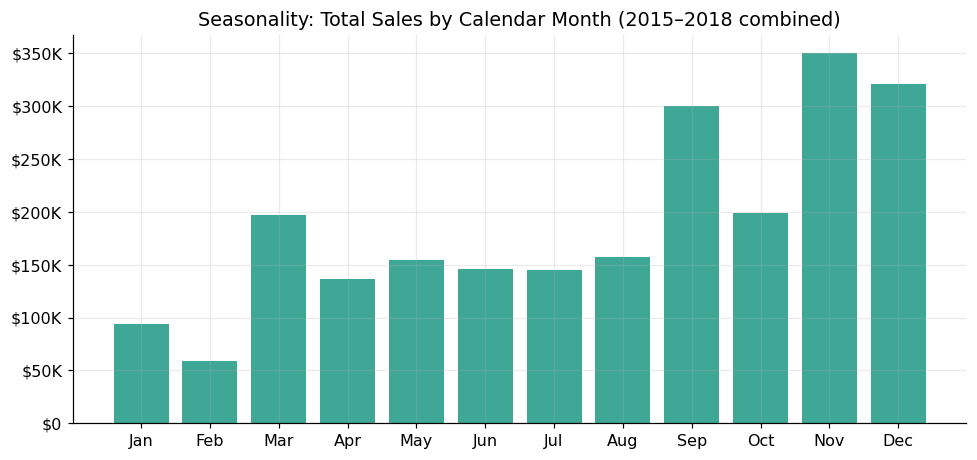

In [11]:
month_sales = df.groupby("Order_Month")["Sales"].sum()
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar([MONTH_NAMES[m-1] for m in month_sales.index], month_sales.values, color="#3FA796")
ax.set_title("Seasonality: Total Sales by Calendar Month (2015–2018 combined)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
plt.tight_layout()
plt.show()


**Finding:** clear seasonality — September (back-to-school), and November/December (holiday season) are by far the strongest months, each roughly 2–3x a typical mid-year month.

## 6. Category, Sub-Category & Product Performance

                         sum  count
Category                           
Technology       827455.8730   1813
Furniture        728658.5757   2078
Office Supplies  705422.3340   5909


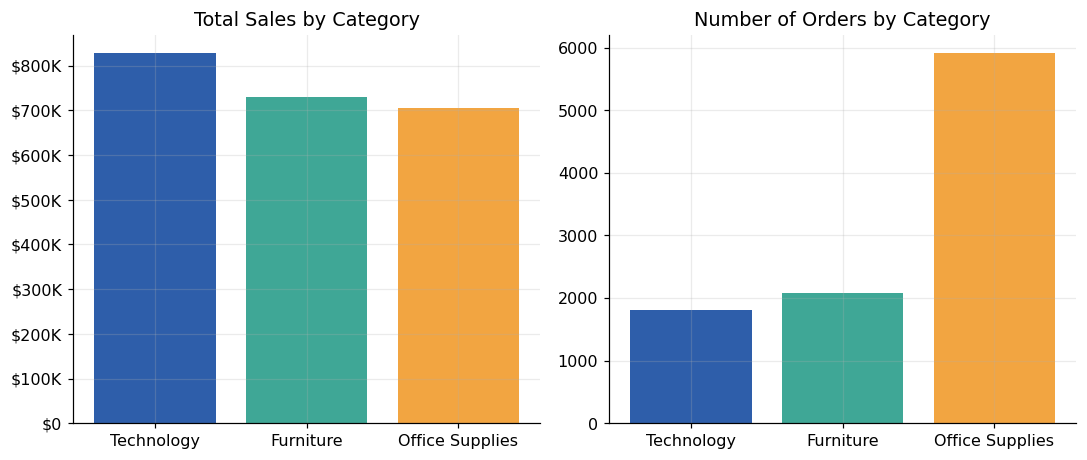

In [12]:
cat = df.groupby("Category")["Sales"].agg(["sum", "count"]).sort_values("sum", ascending=False)
print(cat)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
axes[0].bar(cat.index, cat["sum"], color=CAT_COLORS)
axes[0].set_title("Total Sales by Category")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
axes[1].bar(cat.index, cat["count"], color=CAT_COLORS)
axes[1].set_title("Number of Orders by Category")
plt.tight_layout()
plt.show()


**Finding:** Technology generates the most revenue despite having the fewest orders (highest revenue-per-order); Office Supplies has by far the most orders but the lowest average order value — classic high-frequency/low-value vs. low-frequency/high-value split.

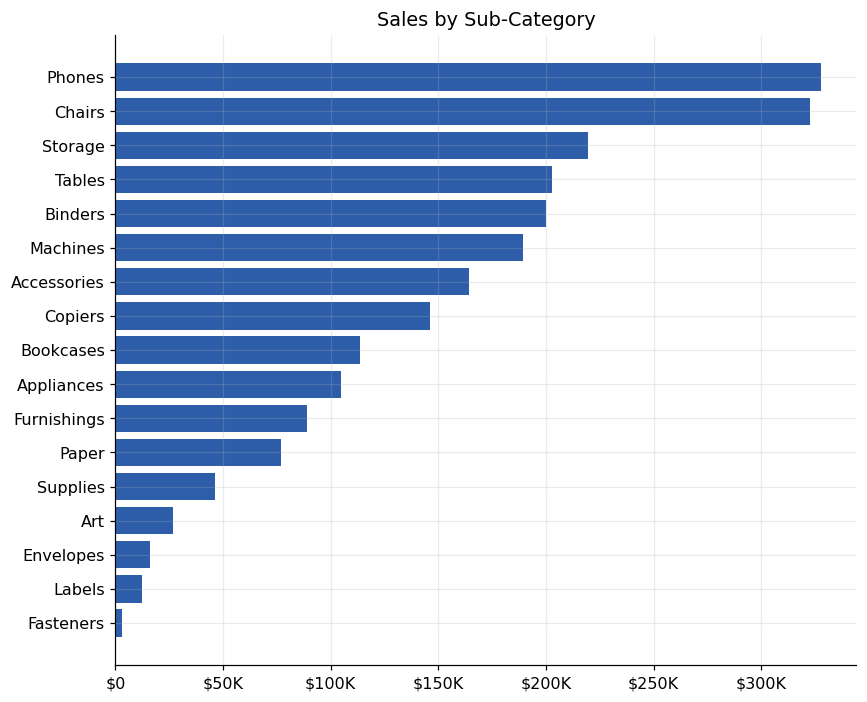

In [13]:
subcat = df.groupby("Sub_Category")["Sales"].sum().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(subcat.index, subcat.values, color="#2E5EAA")
ax.set_title("Sales by Sub-Category")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
plt.tight_layout()
plt.show()


**Finding:** Phones, Chairs, and Storage are the top three sub-categories by revenue, while Fasteners, Labels, and Envelopes trail far behind — these very low-value sub-categories may be better suited as bundled add-ons than standalone marketing focuses.

In [14]:
top_prod = df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_prod


Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

**Finding:** the Canon imageCLASS 2200 Advanced Copier alone generated over $61K — more than double the next best-selling product — making it a clear flagship item worth featuring prominently.

## 7. Regional & State Performance

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


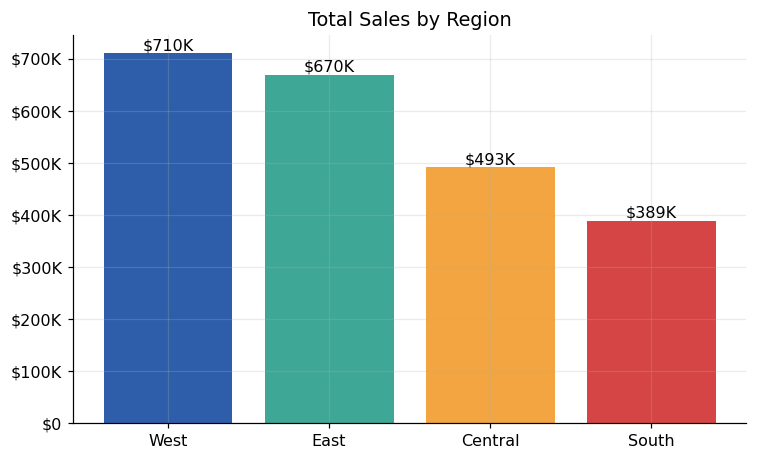

In [15]:
region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(region)

fig, ax = plt.subplots(figsize=(7, 4.3))
bars = ax.bar(region.index, region.values, color=REGION_COLORS)
ax.set_title("Total Sales by Region")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
for b in bars:
    ax.annotate(f"${b.get_height()/1000:.0f}K", (b.get_x()+b.get_width()/2, b.get_height()), ha="center", va="bottom")
plt.tight_layout()
plt.show()


**Finding:** West (31.4%) and East (29.6%) together account for over 60% of total sales, while South (17.2%) lags noticeably behind the other three regions.

Top 10 states:
 State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64

Bottom 10 states:
 State
New Mexico              4783.522
Iowa                    4443.560
Idaho                   4382.486
Kansas                  2914.310
District of Columbia    2865.020
Wyoming                 1603.136
South Dakota            1315.560
Maine                   1270.530
West Virginia           1209.824
North Dakota             919.910
Name: Sales, dtype: float64


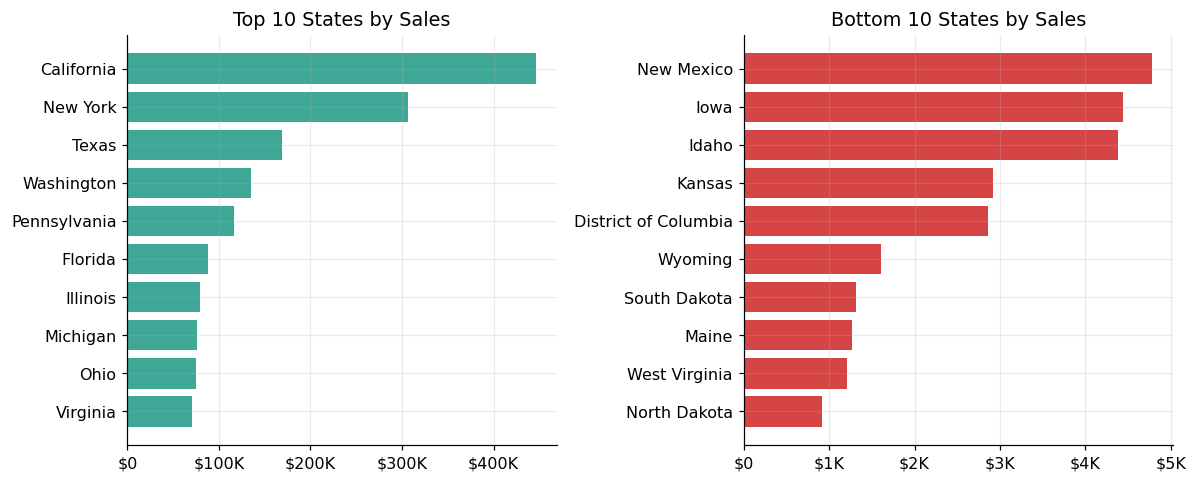

In [16]:
state = df.groupby("State")["Sales"].sum().sort_values(ascending=False)
print("Top 10 states:\n", state.head(10))
print("\nBottom 10 states:\n", state.tail(10))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
top10 = state.head(10).sort_values()
bot10 = state.tail(10).sort_values()
axes[0].barh(top10.index, top10.values, color="#3FA796")
axes[0].set_title("Top 10 States by Sales")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
axes[1].barh(bot10.index, bot10.values, color="#D64545")
axes[1].set_title("Bottom 10 States by Sales")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
plt.tight_layout()
plt.show()


**Finding:** California ($446K) and New York ($306K) dominate, together contributing about a third of all sales. At the other end, several states (North Dakota, West Virginia, Maine, South Dakota) each contributed under $2,000 across the full four-year period — a long tail of very low-activity markets.

## 8. Customer Segment & Concentration Analysis

                      sum  count        mean
Segment                                     
Consumer     1.148061e+06   5101  225.065777
Corporate    6.884941e+05   2953  233.150720
Home Office  4.249822e+05   1746  243.403309


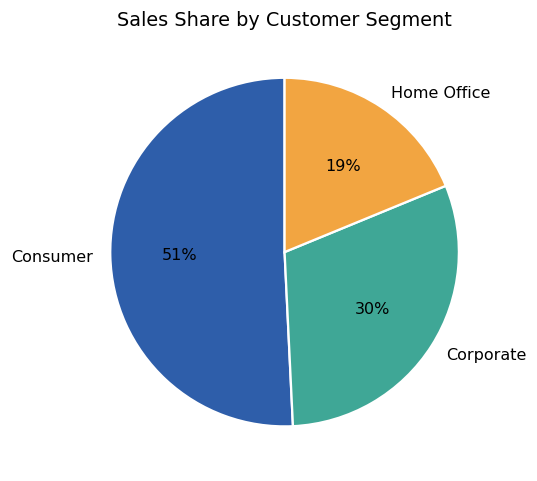

In [17]:
segment = df.groupby("Segment")["Sales"].agg(["sum", "count", "mean"]).sort_values("sum", ascending=False)
print(segment)

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(segment["sum"], labels=segment.index, autopct="%1.0f%%", startangle=90,
       colors=["#2E5EAA", "#3FA796", "#F2A541"], wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Sales Share by Customer Segment")
plt.tight_layout()
plt.show()


**Finding:** Consumer is the largest segment by revenue (50.8%), more than Corporate (30.4%) and Home Office (18.8%) combined — but as the concentration analysis below shows, this isn't just a handful of big consumer accounts driving it.

Customers needed for 80% of revenue: 393 of 793 (49.6%)


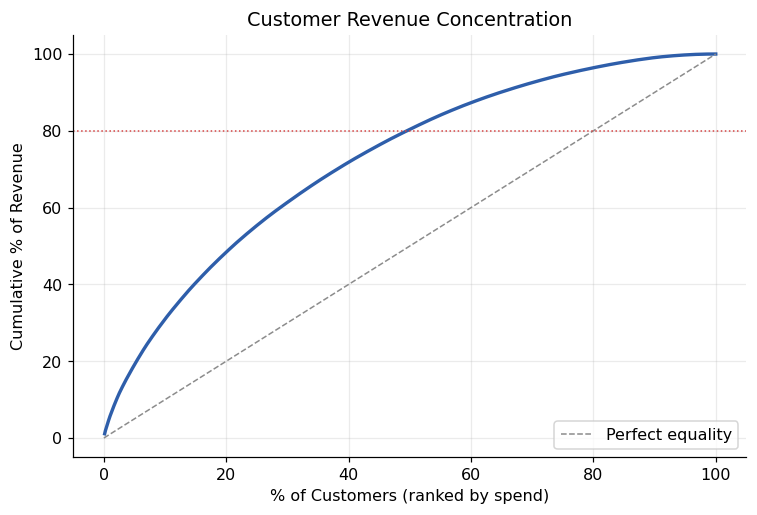

In [18]:
cust_totals = df.groupby("Customer_ID")["Sales"].sum().sort_values(ascending=False).reset_index(drop=True)
cum_pct = cust_totals.cumsum() / cust_totals.sum() * 100
n_for_80 = (cum_pct <= 80).sum() + 1
print(f"Customers needed for 80% of revenue: {n_for_80} of {len(cust_totals)} ({n_for_80/len(cust_totals):.1%})")

cust_pct = (cust_totals.index + 1) / len(cust_totals) * 100
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(cust_pct, cum_pct, color="#2E5EAA", linewidth=2.2)
ax.plot([0, 100], [0, 100], color="#8C8C8C", linestyle="--", linewidth=1, label="Perfect equality")
ax.axhline(80, color="#D64545", linestyle=":", linewidth=1)
ax.set_title("Customer Revenue Concentration")
ax.set_xlabel("% of Customers (ranked by spend)")
ax.set_ylabel("Cumulative % of Revenue")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


**Finding:** revenue is much less concentrated than a typical 80/20 pattern — it takes about **half of all customers (49.6%)** to reach 80% of revenue. This is a healthier, more broad-based customer base than Task 1's e-commerce dataset showed.

## 9. Shipping Mode Analysis

Orders by ship mode:
 Ship_Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64

Average shipping delay (days):
 Ship_Mode
Standard Class    5.01
Second Class      3.25
First Class       2.18
Same Day          0.04
Name: Shipping_Delay_Days, dtype: float64


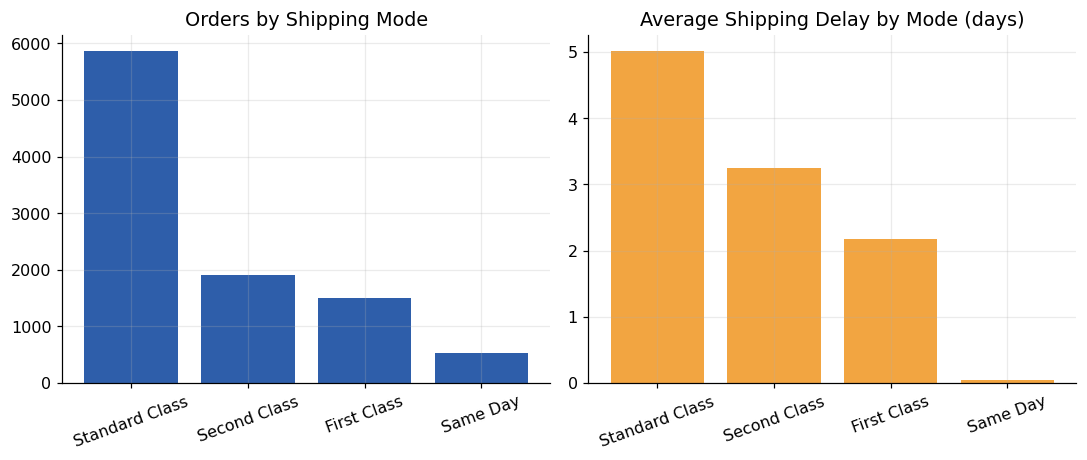

In [19]:
ship_count = df["Ship_Mode"].value_counts()
ship_delay = df.groupby("Ship_Mode")["Shipping_Delay_Days"].mean().reindex(ship_count.index)
print("Orders by ship mode:\n", ship_count)
print("\nAverage shipping delay (days):\n", ship_delay.round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
axes[0].bar(ship_count.index, ship_count.values, color="#2E5EAA")
axes[0].set_title("Orders by Shipping Mode")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(ship_delay.index, ship_delay.values, color="#F2A541")
axes[1].set_title("Average Shipping Delay by Mode (days)")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


**Finding:** Standard Class dominates order volume (~60% of orders) despite having the longest average delay (~5 days) — most customers are choosing the slowest option, which may indicate price sensitivity or that faster options aren't being surfaced/promoted effectively at checkout.

## 10. Key Findings & Recommendations for Alfido Tech

### Key Findings
1. **Sales are growing overall** — a slight dip in 2016 (−4.3%) was followed by strong growth in 2017 (+30.6%) and 2018 (+20.3%).
2. **Strong, predictable seasonality** — September, November, and December are peak months (back-to-school and holiday season), each 2–3x a typical mid-year month.
3. **Technology drives the most revenue per order; Office Supplies drives the most order volume** — different categories serve different roles (high-value vs. high-frequency).
4. **Revenue is broadly distributed across customers** — it takes ~50% of customers to reach 80% of revenue, a healthier spread than typical retail concentration.
5. **Standard Class shipping dominates but is the slowest option** — ~60% of orders use it despite a ~5 day average delay, well behind Same Day (<1 day) and First Class (~2 days).

### 5 Actionable Recommendations
1. **Plan inventory and staffing around the Sep/Nov/Dec peak** — pre-build stock and marketing pushes ahead of these three months specifically, since they concentrate a disproportionate share of annual revenue.
2. **Promote and price faster shipping tiers more assertively** — since most customers default to the slowest option, testing free/discounted upgrades to First Class or Second Class at checkout could improve satisfaction without much revenue risk.
3. **Double down on Technology as a margin/value driver** — its high revenue-per-order makes it a strong candidate for bundling, upselling, and premium placement, even though it has fewer orders than other categories.
4. **Use Office Supplies as a traffic/frequency driver, then cross-sell** — its high order count but low average value makes it a good entry point; pairing it with Technology/Furniture recommendations at checkout could lift overall basket size.
5. **Investigate underperforming states (e.g., North Dakota, West Virginia, Maine)** — targeted regional marketing or distribution changes could unlock incremental revenue in the long tail of states currently contributing very little.
